**Name: Abeer Fatima**

**Roll no: 22F-BSAI-38**

**Department: BSAI (A1)**

**Subject: Deep Learning**

**Teacher: Sir Hamza**

# **Install Libraries**

In [ ]:
!pip install transformers datasets torch -q

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df=pd.read_csv("/content/Clean_Encoded-Data.csv")

# **Imports**

In [ ]:
import torch
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

# **Load ClinicalBERT / BioBERT**

In [ ]:
MODEL_NAME = "emilyalsentzer/Bio_ClinicalBERT"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

# **Prepare Dataset**

In [ ]:
df = df.copy()

def create_notes(row):
    return (
        f"Patient aged {row['age']}. "
        f"Heart rate {row['heart_rate_apache']}. "
        f"Respiratory rate {row['resprate_apache']}. "
        f"Temperature {row['temp_apache']}. "
        f"GCS eye {row['gcs_eyes_apache']} verbal {row['gcs_verbal_apache']}. "
        f"ICU condition critical status based on vitals and APACHE score."
    )

df["clinical_notes"] = df.apply(create_notes, axis=1)

In [ ]:
TEXT_COL = "clinical_notes"
TARGET = "hospital_death"

df = df[[TEXT_COL, TARGET]].dropna()

In [ ]:
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df[TEXT_COL],
    df[TARGET],
    test_size=0.2,
    random_state=42,
    stratify=df[TARGET]
)

In [ ]:
MODEL_NAME = "emilyalsentzer/Bio_ClinicalBERT"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

In [ ]:
train_encodings = tokenizer(list(train_texts), truncation=True, padding=True, max_length=256)
test_encodings  = tokenizer(list(test_texts), truncation=True, padding=True, max_length=256)

In [ ]:
class ClinicalDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.values

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

In [ ]:
train_dataset = ClinicalDataset(train_encodings, train_labels)
test_dataset = ClinicalDataset(test_encodings, test_labels)

# **MODEL 1 — CLINICALBERT (FROZEN)**

In [ ]:
frozen_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

for param in frozen_model.base_model.parameters():
    param.requires_grad = False

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

# **TRAIN FROZEN**

In [ ]:
from transformers import TrainingArguments, Trainer

args_frozen = TrainingArguments(
    output_dir="./frozen",
    num_train_epochs=1,
    per_device_train_batch_size=8,
    eval_strategy="epoch",   # changed here
    save_strategy="no",
    logging_steps=10,
    report_to="none"
)

trainer_frozen = Trainer(
    model=frozen_model,
    args=args_frozen,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

trainer_frozen.train()

Epoch,Training Loss,Validation Loss
1,0.680842,0.685761


TrainOutput(global_step=16760, training_loss=0.6926062131553959, metrics={'train_runtime': 491.1821, 'train_samples_per_second': 272.966, 'train_steps_per_second': 34.122, 'total_flos': 3169406995094880.0, 'train_loss': 0.6926062131553959, 'epoch': 1.0})

In [ ]:
import time

start_time = time.time()

trainer_frozen.train()

end_time = time.time()

training_time = end_time - start_time

print(f"Training Time: {training_time:.2f} seconds")

Epoch,Training Loss,Validation Loss
1,0.673138,0.679597


Training Time: 523.28 seconds


In [ ]:
predictions = trainer_frozen.predict(test_dataset)

In [ ]:
import numpy as np

y_pred = np.argmax(predictions.predictions, axis=1)
y_true = test_labels.values

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("===== ClinicalBERT (Frozen) Results =====")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")
print(f"Training Time: {training_time:.2f} seconds")

===== ClinicalBERT (Frozen) Results =====
Accuracy  : 0.6608
Precision : 0.7649
Recall    : 0.4643
F1-score  : 0.5778
Training Time: 523.28 seconds


In [ ]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.62      0.86      0.72     16760
           1       0.76      0.46      0.58     16760

    accuracy                           0.66     33520
   macro avg       0.69      0.66      0.65     33520
weighted avg       0.69      0.66      0.65     33520



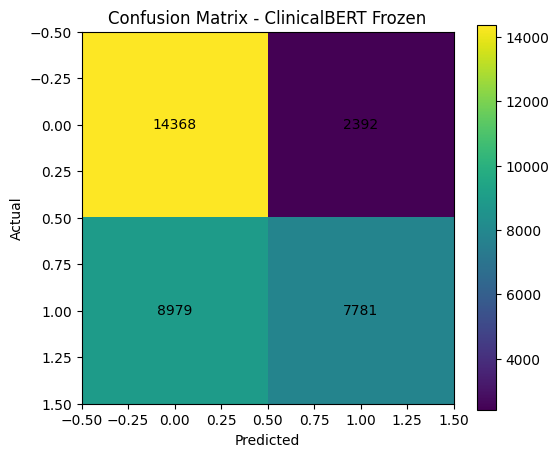

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
plt.imshow(cm)

plt.title("Confusion Matrix - ClinicalBERT Frozen")
plt.colorbar()

plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]),
                 ha='center', va='center')

plt.show()

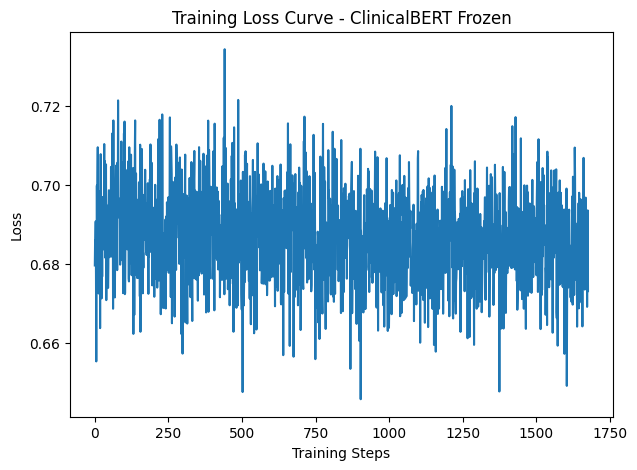

In [ ]:
logs = trainer_frozen.state.log_history

train_loss = [x["loss"] for x in logs if "loss" in x]

plt.figure(figsize=(7,5))

plt.plot(train_loss)

plt.title("Training Loss Curve - ClinicalBERT Frozen")
plt.xlabel("Training Steps")
plt.ylabel("Loss")

plt.show()

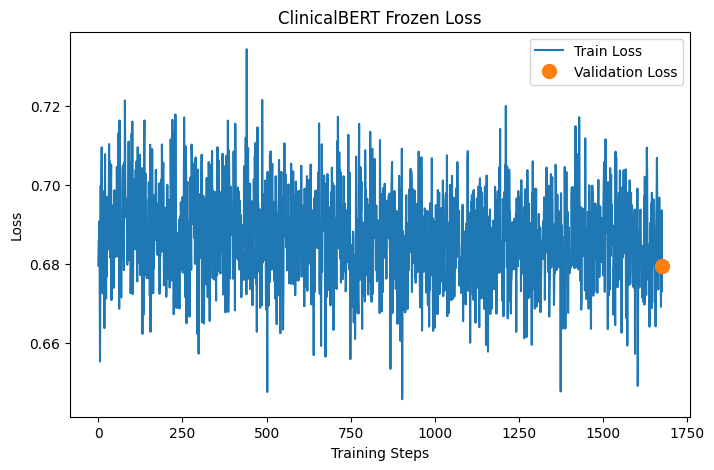

In [ ]:
logs = trainer_frozen.state.log_history

train_loss = [x["loss"] for x in logs if "loss" in x]
eval_loss = [x["eval_loss"] for x in logs if "eval_loss" in x]

plt.figure(figsize=(8,5))

plt.plot(train_loss, label="Train Loss")

if len(eval_loss) > 0:
    plt.plot(
        [len(train_loss)-1],
        eval_loss,
        marker='o',
        markersize=10,
        linestyle='None',
        label="Validation Loss"
    )

plt.title("ClinicalBERT Frozen Loss")
plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.legend()

plt.show()